# NutriClass: Food Classification Using Nutritional Data

## Project Overview
NutriClass is a multi-class machine learning project that classifies a food profile into one of 10 predefined food categories using nutritional and food-related attributes.

### Objective
- Understand and clean the food dataset.
- Explore nutritional differences between food classes.
- Compare seven machine learning classifiers.
- Evaluate models using Accuracy, Precision, Recall, F1-score, and Confusion Matrices.
- Validate the final model using 5-fold stratified cross-validation.
- Identify influential features and demonstrate food prediction on new input data.

### Target Variable
`Food_Name`

### Food Classes
Apple, Banana, Burger, Donut, Ice Cream, Pasta, Pizza, Salad, Steak, Sushi

## Business Use Cases

1. **Smart Dietary Applications** — classify food profiles for nutrition-focused applications.
2. **Health Monitoring Tools** — support nutritionists and diet-planning workflows.
3. **Food Logging Systems** — automatically classify user-entered food profiles.
4. **Educational Platforms** — demonstrate how nutritional attributes differ across food categories.
5. **Grocery / Meal Planning** — support automated food classification and same-category alternatives.

## Problem Statement

The objective is to develop a robust multi-class classification system that predicts the food category associated with a given nutritional profile. The project uses numerical nutritional attributes together with meal type, preparation method, and dietary indicators.

The implementation is a **classification system**, not a complete diet recommendation or nutritional optimization engine. It predicts the most likely predefined food category from the supplied input profile.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## Loading the dataset

In [12]:
df = pd.read_csv("synthetic_food_dataset_imbalanced.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Checking dataset dimensions

In [13]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 31700
Number of Columns: 16


### Result interpretation

The dataset contains **31,700 rows and 16 columns**.

**What this tells us:**  
The dataset is large enough for a meaningful train/test split and for comparing several classification algorithms.

## Viewing the first 5 records

In [14]:
df.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


### Result interpretation

The first five rows give an initial view of the numerical nutritional attributes, categorical information, Boolean dietary flags, and the target variable `Food_Name`.

## Checking the last 5 records

In [15]:
df.tail()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
31695,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,81.784216,120.293342,lunch,fried,True,True,Banana
31696,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,192.062481,lunch,raw,False,False,Pizza
31697,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,197.318164,breakfast,grilled,False,False,Pizza
31698,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,152.072098,dinner,grilled,False,False,Pasta
31699,203.952826,5.322650,13.419346,26.686660,14.645211,0.295026,62.468736,38.417093,57.987511,51.156165,113.912626,breakfast,grilled,False,True,Ice Cream


### Result interpretation

The last five records confirm that the dataset was loaded completely and allow us to verify the structure at the end of the DataFrame as well.

**Key takeaway:** the dataset is structurally consistent from beginning to end.

## Checking column names

In [16]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']


### Result interpretation

The column list identifies the full feature set and confirms that `Food_Name` is the prediction target.

The input data contains **15 predictors** and one target column.

## Understand the data types

In [17]:
df.dtypes

Calories              float64
Protein               float64
Fat                   float64
Carbs                 float64
Sugar                 float64
Fiber                 float64
Sodium                float64
Cholesterol           float64
Glycemic_Index        float64
Water_Content         float64
Serving_Size          float64
Meal_Type              object
Preparation_Method     object
Is_Vegan                 bool
Is_Gluten_Free           bool
Food_Name              object
dtype: object

### Result interpretation

The dataset contains **11 numerical features**, **3 object/string columns** (`Meal_Type`, `Preparation_Method`, `Food_Name`), and **2 Boolean features**.

**Why this matters:** different data types require different preprocessing strategies later in the pipeline.

## Detailed dataset informations

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

### Result interpretation

`df.info()` confirms the dataset size, data types, and the presence of missing values in the numerical nutritional columns.

# 7. Exploratory Data Analysis (EDA)

The EDA stage examines dataset quality, class balance, feature distributions, relationships among nutritional variables, and differences between food categories.

## Missing Values

In [19]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_table = missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

missing_table

,Missing Values,Missing Percentage
Calories,375,1.18
Protein,375,1.18
Fat,375,1.18
Carbs,375,1.18
Sugar,375,1.18
Fiber,375,1.18
Sodium,375,1.18
Cholesterol,375,1.18
Glycemic_Index,375,1.18
Water_Content,375,1.18


### Missing-value interpretation

Each of the 11 numerical nutritional variables contains **375 missing values (1.18%)**. The categorical, Boolean, and target columns have no missing values.

**Important observation:** the missing numerical values occur together, so these records do not contain enough nutritional information for reliable numerical imputation.

**Decision:** I will remove these incomplete nutritional records during data cleaning.

In [20]:
df[df.isnull().any(axis=1)].head(10)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snack,raw,False,False,Burger
110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,breakfast,grilled,False,False,Donut
150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunch,baked,False,False,Pizza
167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunch,baked,False,False,Burger
216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,snack,grilled,False,True,Steak
246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dinner,raw,True,True,Salad
391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dinner,baked,False,False,Pizza
397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dinner,raw,False,False,Pizza
676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunch,fried,False,False,Pizza
695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunch,baked,False,False,Pizza


In [21]:
df[df.isnull().any(axis=1)].isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

## Duplicate Records

In [22]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 313


### Duplicate interpretation

The dataset contains **313 duplicate rows**.

**Why this matters:** duplicate observations can cause repeated information to influence model training disproportionately.

**Decision:** exact duplicate rows will be removed during data cleaning.

## Basic Statistical Analysis

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Calories,31325.0,273.378441,111.457160,60.786204,210.301731,281.774249,329.821946,1289.956763
Protein,31325.0,9.523802,8.024212,0.000000,3.858307,9.091637,12.683957,81.761772
Fat,31325.0,12.476848,8.425834,0.000000,8.245636,11.574161,15.818611,88.619611
Carbs,31325.0,28.943200,12.668795,0.000000,25.098800,29.681430,34.635789,140.585537
Sugar,31325.0,8.543813,7.989075,0.000000,3.739656,5.500479,14.426303,78.548162
Fiber,31325.0,1.904044,1.779542,0.000000,0.741204,1.646608,2.668750,18.891993
Sodium,31325.0,335.387611,319.066106,0.000000,63.000654,292.525242,631.367901,2724.236846
Cholesterol,31325.0,26.865167,24.965067,0.000000,12.701920,23.285882,35.132214,260.149443
Glycemic_Index,31325.0,64.213509,25.390239,0.000000,59.984731,68.436204,75.464697,286.126400
Water_Content,31325.0,48.976592,20.738749,13.465039,38.994221,45.613748,52.399496,251.837472


### Statistical-summary interpretation

The descriptive statistics show the scale and variability of the nutritional features. The ranges also highlight potentially extreme values, which motivates the later outlier investigation.
 
“I used the summary statistics to understand central tendency, spread, and the range of each nutritional feature before deciding how to treat extreme observations.”

## Identifying Numerical & Categorical Columns

In [24]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

boolean_columns = df.select_dtypes(
    include=["bool"]
).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nBoolean Columns:")
print(boolean_columns)

Numerical Columns:
['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size']

Categorical Columns:
['Meal_Type', 'Preparation_Method', 'Food_Name']

Boolean Columns:
['Is_Vegan', 'Is_Gluten_Free']


## Target Variable

In [25]:
target = "Food_Name"

In [26]:
print("Number of unique food classes:", df["Food_Name"].nunique())

Number of unique food classes: 10


### Target interpretation

The dataset contains **10 food classes**.

The target is `Food_Name`, so this is a **10-class multi-class classification problem**.

In [27]:
print(df["Food_Name"].unique())

['Pizza' 'Ice Cream' 'Burger' 'Sushi' 'Donut' 'Steak' 'Apple' 'Banana'
 'Pasta' 'Salad']


## Class Distribution

In [28]:
class_counts = df["Food_Name"].value_counts()

print(class_counts)

Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64


### Class-distribution interpretation

The target is imbalanced: **Pizza has 6,000 records while Salad has 1,000**.

**Why this matters:** model evaluation should not rely on accuracy alone. I therefore track **Precision, Recall, Weighted F1, and especially Macro F1**, which gives each food class equal importance.

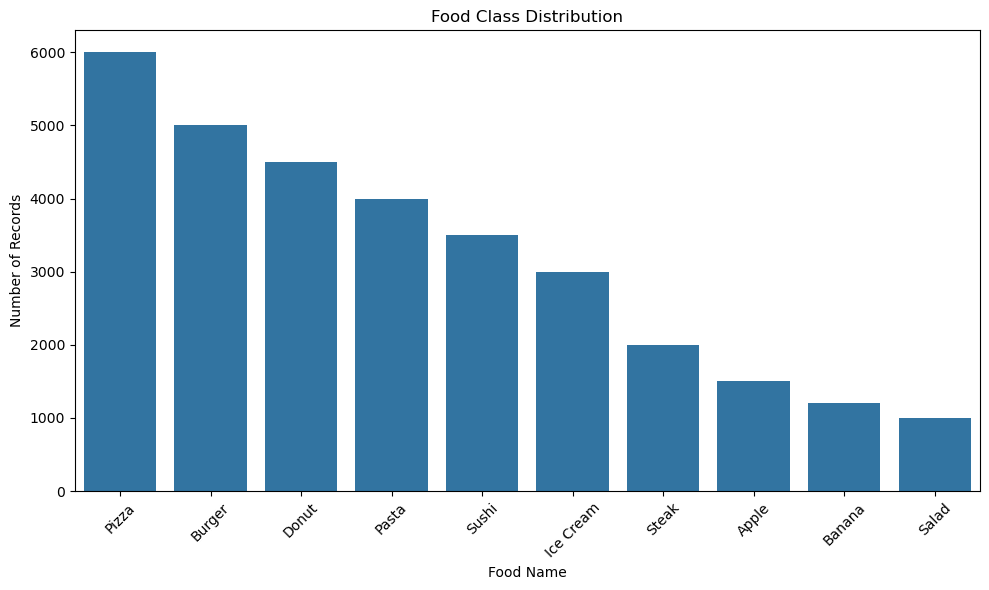

In [29]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Food_Name",
    order=df["Food_Name"].value_counts().index
)

plt.title("Food Class Distribution")
plt.xlabel("Food Name")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Visualization interpretation

The class-distribution chart makes the target imbalance immediately visible.

**Key takeaway:** the benchmark contains enough examples for all classes, but the class frequencies are not equal, so imbalance-aware evaluation is important.

## Categorical Feature Distribution

### Meal Type

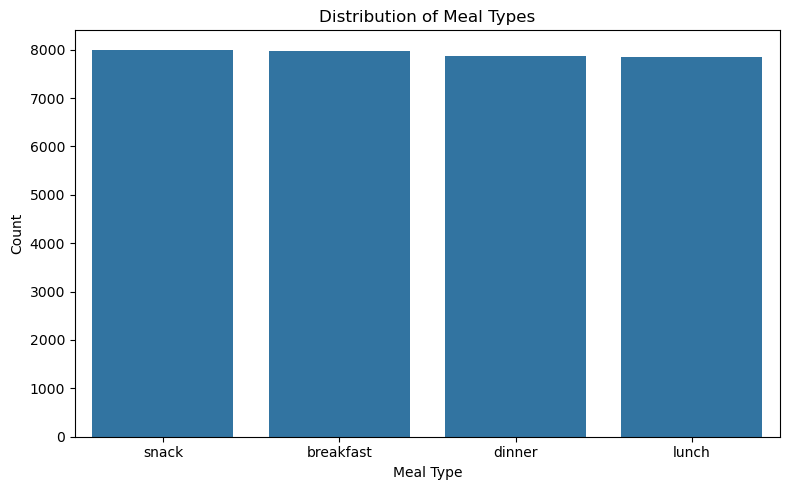

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Meal_Type",
    order=df["Meal_Type"].value_counts().index
)

plt.title("Distribution of Meal Types")
plt.xlabel("Meal Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Meal-type interpretation

The four meal categories are represented relatively evenly.

**Key takeaway:** Meal Type does not show a major distribution imbalance and can be retained as an input feature.

### Preparation Method

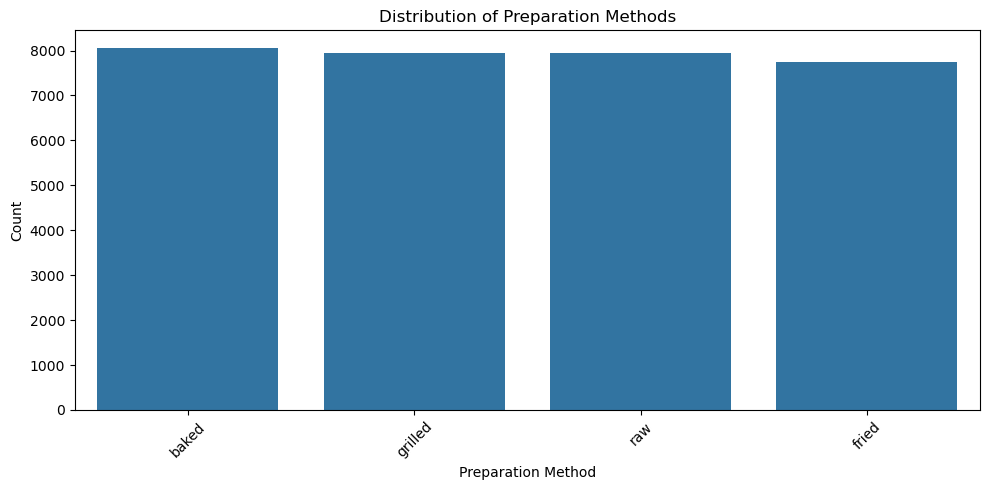

In [31]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Preparation_Method",
    order=df["Preparation_Method"].value_counts().index
)

plt.title("Distribution of Preparation Methods")
plt.xlabel("Preparation Method")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Preparation-method interpretation

Baked, grilled, raw, and fried preparation methods are also represented with broadly similar frequencies.

**Key takeaway:** there is no major preparation-method imbalance that requires corrective sampling.

## Boolean Features

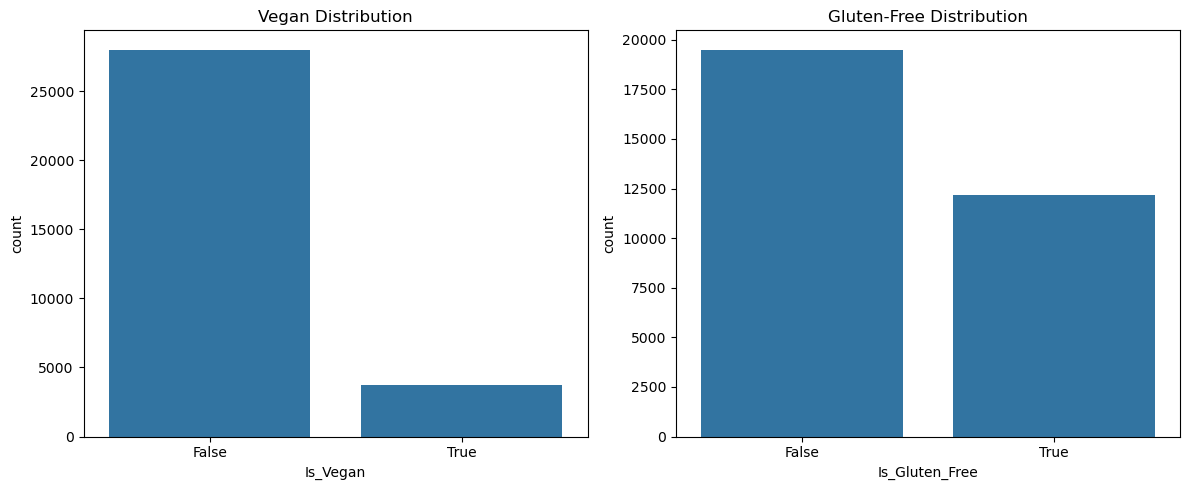

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Is_Vegan", ax=axes[0])
axes[0].set_title("Vegan Distribution")

sns.countplot(data=df, x="Is_Gluten_Free", ax=axes[1])
axes[1].set_title("Gluten-Free Distribution")

plt.tight_layout()
plt.show()

### Boolean-feature interpretation

`Is_Vegan` is substantially less frequent as `True`, while `Is_Gluten_Free` has a broader split between `True` and `False`.

**Why this matters:** these features may still carry predictive information, so I retain them and allow the model to determine their usefulness.

## Correlation Analysis

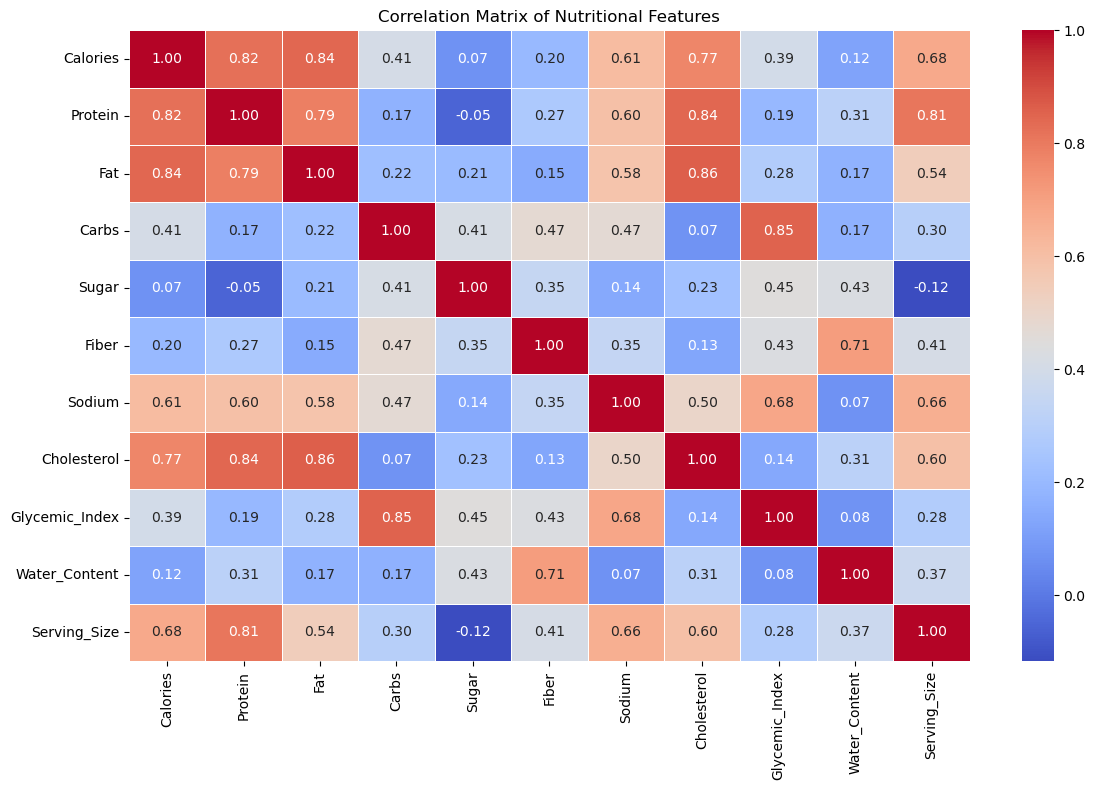

In [33]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Nutritional Features")
plt.tight_layout()
plt.show()

### Correlation interpretation

The correlation matrix shows several strong relationships, including:

- Calories with Protein and Fat
- Protein with Cholesterol
- Fat with Cholesterol
- Carbs with Glycemic Index

**Why this matters:** nutritional variables are related rather than independent. Tree-based and ensemble models can use these interactions effectively, while scaling is particularly important for distance- and margin-based models.

## Nutritional Features by Food

In [34]:
food_means = df.groupby("Food_Name")[numeric_columns].mean()

food_means.round(2)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
Food_Name,,,,,,,,,,,
Apple,102.79,1.05,0.90,25.78,19.38,4.10,20.48,1.77,41.41,86.31,152.49
Banana,110.86,1.71,0.85,27.44,14.24,3.11,14.85,1.32,53.05,75.03,122.46
Burger,356.41,14.42,19.40,30.65,6.47,2.11,712.58,41.57,71.27,46.38,182.36
Donut,264.12,4.36,14.30,31.52,16.30,1.07,310.47,21.07,75.89,31.12,82.09
Ice Cream,217.97,3.63,11.57,25.93,18.46,0.65,90.74,36.70,61.66,51.60,103.64
Pasta,322.13,8.17,10.17,40.21,3.16,2.07,26.40,10.58,65.64,45.63,150.77
Pizza,303.98,12.31,12.43,33.50,5.35,2.11,650.38,26.04,80.88,40.93,201.48
Salad,123.08,3.24,5.35,10.39,3.23,5.05,68.37,0.79,35.85,90.24,101.65
Steak,402.96,25.26,25.41,0.84,0.44,0.09,101.74,80.98,1.70,55.95,201.47


### Food-level nutritional interpretation

The group-wise means show clear nutritional signatures across food categories.

For example:

- **Steak** has very high Protein, Fat, and Cholesterol with almost no Carbohydrates.
- **Pizza and Burger** have relatively high Sodium.
- **Salad** has high Water Content and Fiber with relatively low Calories.
- **Apple and Banana** have low Calories and Fat compared with the processed food categories.

**Key takeaway:** the target classes are nutritionally separable, which helps explain the high classification performance later.

### Calories

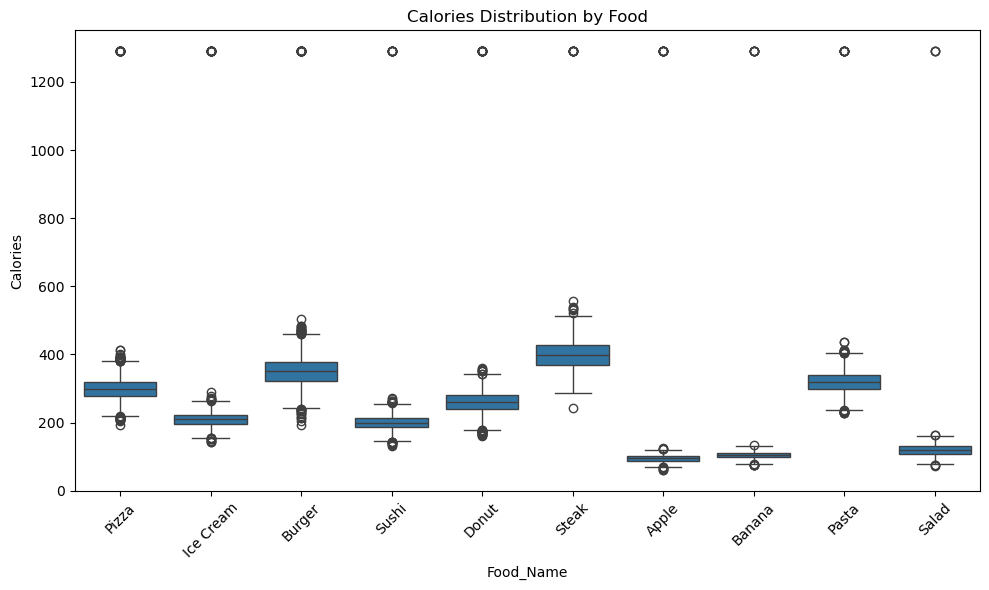

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Food_Name",
    y="Calories"
)

plt.title("Calories Distribution by Food")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Calories interpretation

The calorie distributions differ substantially between food categories. This suggests that Calories provide useful classification information, although they are not expected to be the only deciding feature.

### Protein

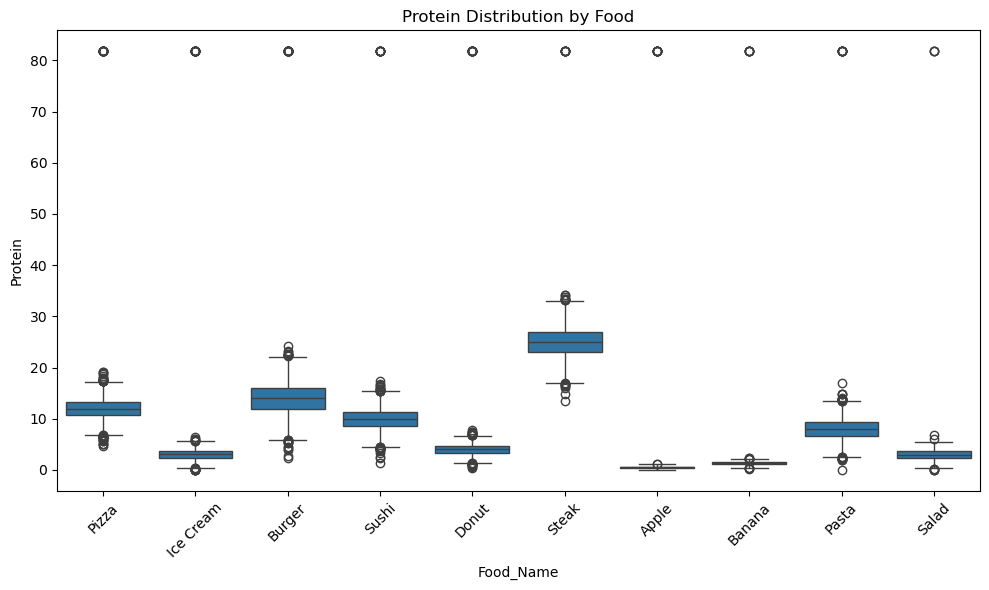

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Food_Name",
    y="Protein"
)

plt.title("Protein Distribution by Food")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Protein interpretation

Protein shows particularly strong separation for categories such as Steak, Burger, Pizza, and the fruit classes.

**Key takeaway:** Protein is likely to be a useful predictor, which is confirmed later by the final model's feature importance analysis.

### Sugar

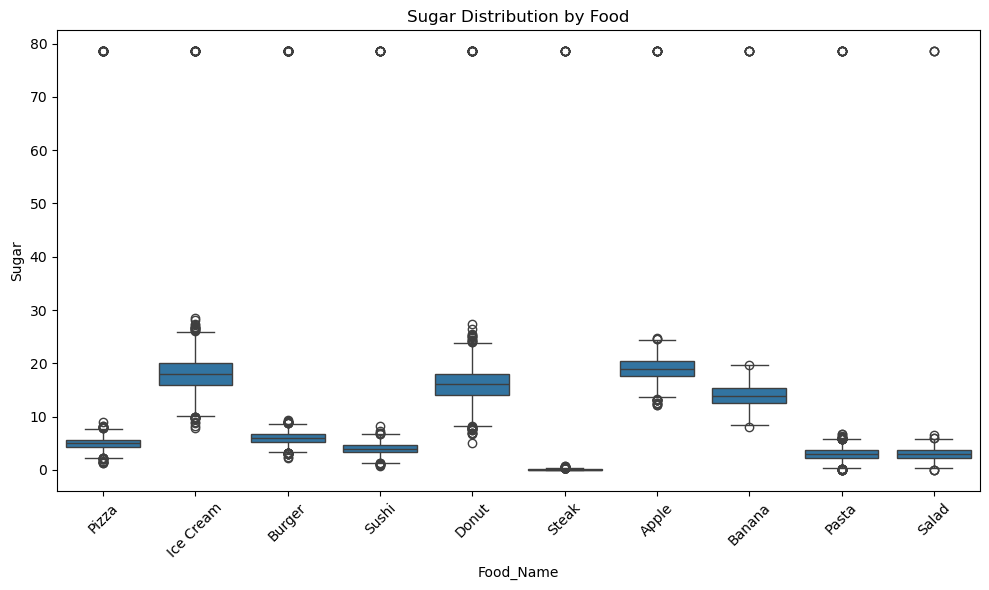

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Food_Name",
    y="Sugar"
)

plt.title("Sugar Distribution by Food")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Sugar interpretation

Sugar distributions help separate categories such as Ice Cream and Donut from low-sugar foods such as Steak, while fruits show their own distinct pattern.

**Key takeaway:** Sugar contributes useful information, but the final model will determine its relative importance.

# EDA conclusion

EDA revealed significant nutritional differences across food categories. Steak exhibited the highest average protein, fat and cholesterol, while fruits such as Apple and Banana showed relatively low calorie and fat levels. Pizza and Burger showed comparatively high sodium levels, while Salad had high water and fiber content with relatively low calories. Strong correlations were observed between Calories and Fat, Protein and Cholesterol, and Carbohydrates and Glycemic Index. The target variable showed class imbalance, with Pizza as the most represented class and Salad as the least represented class. Several extreme numerical observations were also identified and will be investigated during preprocessing.

### EDA conclusion

The EDA shows that the food classes have noticeably different nutritional profiles. The strongest differences are visible in features such as Protein, Fat, Sodium, Cholesterol, Carbohydrates, Water Content, and Serving Size.

These observations justify proceeding with a supervised multi-class classification approach.

# 8. Data Cleaning

The original dataset contains 31,700 records. Rows with all nutritional predictors missing are removed because they do not contain sufficient numerical information for classification. Exact duplicate records are then removed.

The resulting clean dataset contains **31,260 rows and 16 columns**.

# Cleaning Execution

In [38]:
# Create a copy of the original dataset
df_clean = df.copy()

print("Original shape:", df_clean.shape)

# Remove rows where all numerical features are missing
df_clean = df_clean.dropna(subset=numeric_columns, how="all")

print("After removing rows with missing nutritional data:", df_clean.shape)

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", df_clean.shape)

# Check remaining missing values
print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Original shape: (31700, 16)
After removing rows with missing nutritional data: (31325, 16)
After removing duplicates: (31260, 16)

Remaining missing values:
Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64


In [39]:
print("Rows removed:", len(df) - len(df_clean))
print("Final cleaned shape:", df_clean.shape)

Rows removed: 440
Final cleaned shape: (31260, 16)


### Data-cleaning result

The cleaning process produced the following dataset progression:

- Original: **31,700 rows**
- After removing incomplete nutritional records: **31,325 rows**
- After removing duplicates: **31,260 rows**

No missing values remain.

**Key takeaway:** the final modeling dataset contains **31,260 complete, non-duplicate observations**.

# 9. Initial Feature Setup and Train/Test Split

The target is `Food_Name`. The initial 80/20 stratified split is used for the seven-model benchmark. Stratification preserves the relative distribution of the 10 food classes in the training and test sets.

## Feature Setup and Train/Test Split

In [40]:
from sklearn.model_selection import train_test_split

X = df_clean.drop("Food_Name", axis=1)
y = df_clean["Food_Name"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25008, 15)
Testing data: (6252, 15)


### Train/test-split interpretation

I used an **80/20 stratified split**:

- Training: **25,008 rows**
- Testing: **6,252 rows**

`stratify=y` preserves the class proportions across the training and test sets.

**Why this matters:** the test set remains representative of the imbalanced food classes.

## Preprocessing Pipeline

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [42]:
numeric_features = [
    'Calories',
    'Protein',
    'Fat',
    'Carbs',
    'Sugar',
    'Fiber',
    'Sodium',
    'Cholesterol',
    'Glycemic_Index',
    'Water_Content',
    'Serving_Size'
]

categorical_features = [
    'Meal_Type',
    'Preparation_Method'
]

boolean_features = [
    'Is_Vegan',
    'Is_Gluten_Free'
]

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bool', 'passthrough', boolean_features)
    ]
)

### Test the preprocessing

In [44]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (25008, 15)
Processed training shape: (25008, 21)
Original testing shape: (6252, 15)
Processed testing shape: (6252, 21)


### Preprocessing interpretation

The original 15 predictors become **21 processed features**:

- 11 numerical features are standardized using `StandardScaler`
- `Meal_Type` and `Preparation_Method` are one-hot encoded
- Boolean variables are passed through

**Key takeaway:** preprocessing is handled consistently through a `ColumnTransformer` and later inside Scikit-learn pipelines.

### Encode the Target

In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Apple' 'Banana' 'Burger' 'Donut' 'Ice Cream' 'Pasta' 'Pizza' 'Salad'
 'Steak' 'Sushi']


### Target-encoding interpretation

`Food_Name` is converted from text labels into numerical class labels **0–9** for model training.

The original food names are preserved by the `LabelEncoder` so predictions can be converted back into readable food names.

In [46]:
print("\nEncoded classes:")
print(np.unique(y_train_encoded))


Encoded classes:
[0 1 2 3 4 5 6 7 8 9]


# 10. Baseline Model Benchmark

## Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [48]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [49]:
logistic_model.fit(X_train, y_train_encoded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Calories', 'Protein', 'Fat',
                                                   'Carbs', 'Sugar', 'Fiber',
                                                   'Sodium', 'Cholesterol',
                                                   'Glycemic_Index',
                                                   'Water_Content',
                                                   'Serving_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Meal_Type',
                                                   'Preparation_Method']),
                                                 ('bool', 'passthrough',
                                                  ['Is_Vegan',
                                                   'Is_Gluten_Free'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [50]:
y_pred_lr = logistic_model.predict(X_test)

In [51]:
lr_accuracy = accuracy_score(y_test_encoded, y_pred_lr)

lr_precision = precision_score(
    y_test_encoded,
    y_pred_lr,
    average='weighted'
)

lr_recall = recall_score(
    y_test_encoded,
    y_pred_lr,
    average='weighted'
)

lr_f1 = f1_score(
    y_test_encoded,
    y_pred_lr,
    average='weighted'
)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9939
Precision: 0.9940
Recall   : 0.9939
F1 Score : 0.9939


In [52]:
lr_f1_macro = f1_score(
    y_test_encoded,
    y_pred_lr,
    average='macro'
)

print(f"Macro F1: {lr_f1_macro:.4f}")

Macro F1: 0.9937


## Reusable Model Evaluation Function

In [53]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average='weighted'
    )
    recall = recall_score(
        y_test, y_pred, average='weighted'
    )
    weighted_f1 = f1_score(
        y_test, y_pred, average='weighted'
    )
    macro_f1 = f1_score(
        y_test, y_pred, average='macro'
    )
    
    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")
    
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1
    }

In [54]:
# Create our results list
results = []

In [55]:
results.append(
    evaluate_model(
        logistic_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "Logistic Regression"
    )
)


Logistic Regression
Accuracy     : 0.9939
Precision    : 0.9940
Recall       : 0.9939
Weighted F1  : 0.9939
Macro F1     : 0.9937


### Logistic Regression — result interpretation

**Accuracy:** 99.39%  
**Macro F1:** 99.37%

Logistic Regression provides an excellent baseline. Its strong performance indicates that the nutritional features already contain strong class-separating information.

“I started with Logistic Regression as a simple linear baseline before moving to more complex non-linear and ensemble models.”

## Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

In [57]:
results.append(
    evaluate_model(
        decision_tree_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "Decision Tree"
    )
)


Decision Tree
Accuracy     : 0.9872
Precision    : 0.9872
Recall       : 0.9872
Weighted F1  : 0.9872
Macro F1     : 0.9887


### Decision Tree — result interpretation

**Accuracy:** 98.72%  
**Macro F1:** 98.87%

The Decision Tree performs well but is below the other leading models.

**Interpretation:** a single tree captures important decision boundaries, but an individual tree is less robust than ensemble methods for this dataset.

## Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [59]:
results.append(
    evaluate_model(
        random_forest_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "Random Forest"
    )
)


Random Forest
Accuracy     : 0.9946
Precision    : 0.9946
Recall       : 0.9946
Weighted F1  : 0.9946
Macro F1     : 0.9948


### Random Forest — result interpretation

**Accuracy:** 99.46%  
**Macro F1:** 99.48%

Random Forest substantially improves on a single Decision Tree and becomes one of the strongest benchmark models.

**Why:** combining many trees helps reduce the instability and overfitting risk of a single tree.

## K-Nearest Neighbors

In [60]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

In [61]:
results.append(
    evaluate_model(
        knn_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "KNN"
    )
)


KNN
Accuracy     : 0.9925
Precision    : 0.9925
Recall       : 0.9925
Weighted F1  : 0.9925
Macro F1     : 0.9923


### KNN — result interpretation

**Accuracy:** 99.25%  
**Macro F1:** 99.23%

KNN performs strongly, which is consistent with the idea that observations with similar nutritional profiles tend to belong to similar food classes.

It is slightly below Random Forest, XGBoost, SVM, and Gradient Boosting on this dataset.

## Support Vector Machine (SVM)

In [62]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        random_state=42
    ))
])

In [63]:
results.append(
    evaluate_model(
        svm_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "SVM"
    )
)


SVM
Accuracy     : 0.9946
Precision    : 0.9946
Recall       : 0.9946
Weighted F1  : 0.9946
Macro F1     : 0.9944


### SVM — result interpretation

**Accuracy:** 99.46%  
**Macro F1:** 99.44%

SVM is one of the strongest benchmark models.

**Interpretation:** the standardized numerical features create a highly separable feature space, allowing the RBF kernel to distinguish the food categories effectively.

## XGBoost

In [64]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.1.3


In [65]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

In [66]:
results.append(
    evaluate_model(
        xgb_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "XGBoost"
    )
)


XGBoost
Accuracy     : 0.9946
Precision    : 0.9946
Recall       : 0.9946
Weighted F1  : 0.9946
Macro F1     : 0.9949


### XGBoost — result interpretation

**Accuracy:** 99.46%  
**Macro F1:** 99.49%

XGBoost is among the top-performing models and slightly exceeds Random Forest on Macro F1 in the initial benchmark.

**Key takeaway:** ensemble boosting methods are particularly well suited to the non-linear relationships in the nutritional features.

## Gradient Boosting

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [74]:
results.append(
    evaluate_model(
        gradient_boosting_model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded,
        "Gradient Boosting"
    )
)


Gradient Boosting
Accuracy     : 0.9952
Precision    : 0.9952
Recall       : 0.9952
Weighted F1  : 0.9952
Macro F1     : 0.9953


### Gradient Boosting — result interpretation

**Initial benchmark:** approximately **99.52% accuracy** and **99.53% Macro F1**.

Gradient Boosting is the strongest initial benchmark model, so it becomes the candidate model for the final refinement stage.

**Important:** this is the initial benchmark. The final model below adds the project-required outlier capping and is evaluated again separately.

## Baseline Model Comparison

In [75]:
results_df = pd.DataFrame(results)

results_df = results_df.drop_duplicates(
    subset=["Model"],
    keep="last"
).reset_index(drop=True)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Gradient Boosting,0.995202,0.995209,0.995202,0.995202,0.995284
1,XGBoost,0.994562,0.994572,0.994562,0.994562,0.994913
2,Random Forest,0.994562,0.994573,0.994562,0.994563,0.994798
3,SVM,0.994562,0.994594,0.994562,0.994569,0.994369
4,Logistic Regression,0.993922,0.993965,0.993922,0.993929,0.993697
5,KNN,0.992482,0.992515,0.992482,0.992487,0.992315
6,Decision Tree,0.987204,0.987234,0.987204,0.987212,0.988674


### Benchmark comparison interpretation

All seven models perform strongly, but Gradient Boosting gives the best initial benchmark performance.

**Initial ranking:** Gradient Boosting → XGBoost → Random Forest → SVM → Logistic Regression → KNN → Decision Tree.

This establishes the baseline before the final data-refinement step.

### Performance Comparison

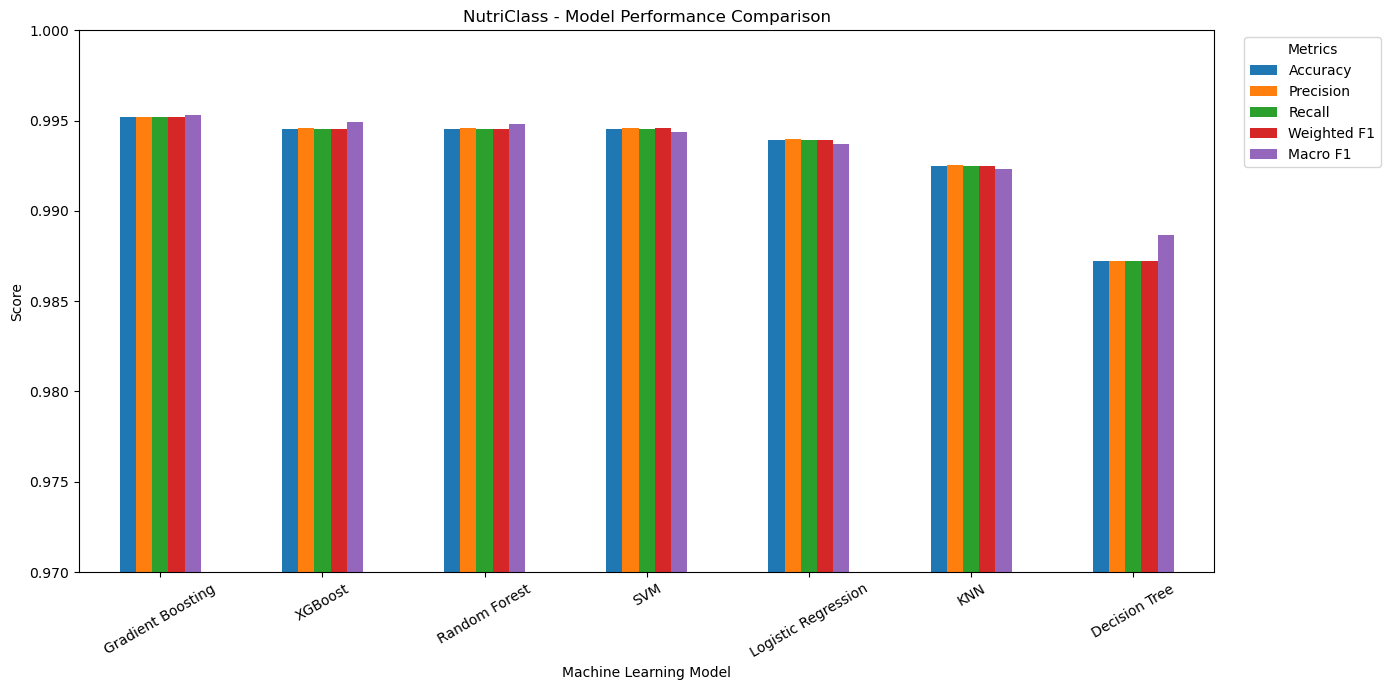

In [76]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'Weighted F1',
    'Macro F1'
]

comparison_df = results_df.set_index('Model')[metrics]

comparison_df.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title("NutriClass - Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0.97, 1.00)

plt.xticks(rotation=30)
plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Performance-comparison interpretation

The grouped bar chart compares Accuracy, Precision, Recall, Weighted F1, and Macro F1 across all seven models.

**Key takeaway:** the leading models are very close to one another, so the final model should be selected using the complete validation picture rather than one metric alone.

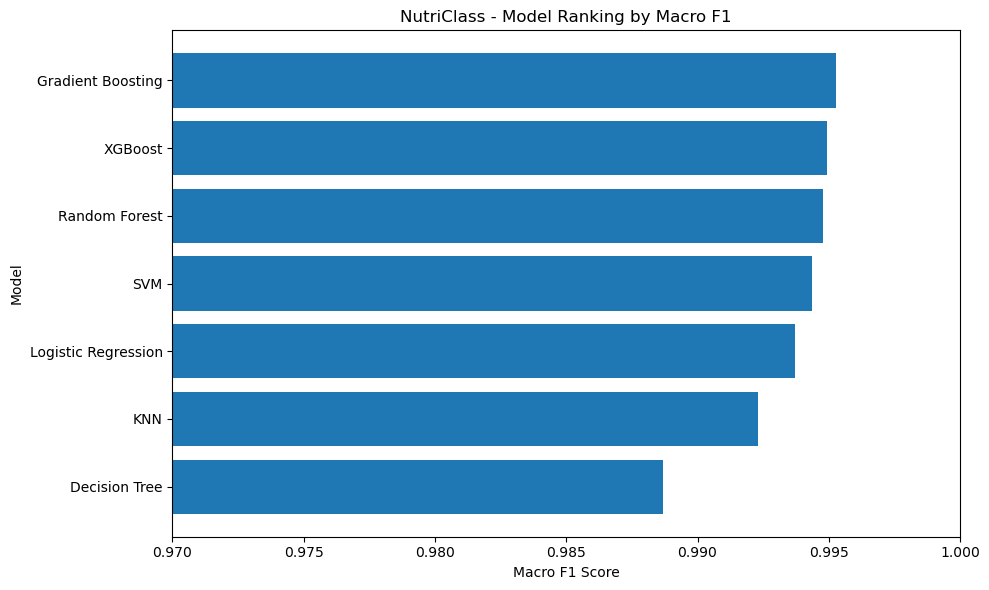

In [77]:
plt.figure(figsize=(10, 6))

ranking_df = results_df.sort_values(
    'Macro F1',
    ascending=True
)

plt.barh(
    ranking_df['Model'],
    ranking_df['Macro F1']
)

plt.title("NutriClass - Model Ranking by Macro F1")
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")
plt.xlim(0.97, 1.00)

plt.tight_layout()
plt.show()

### Macro-F1 ranking interpretation

Macro F1 is emphasized because the target is imbalanced. The chart confirms that Gradient Boosting is the strongest initial benchmark, followed closely by XGBoost and Random Forest.

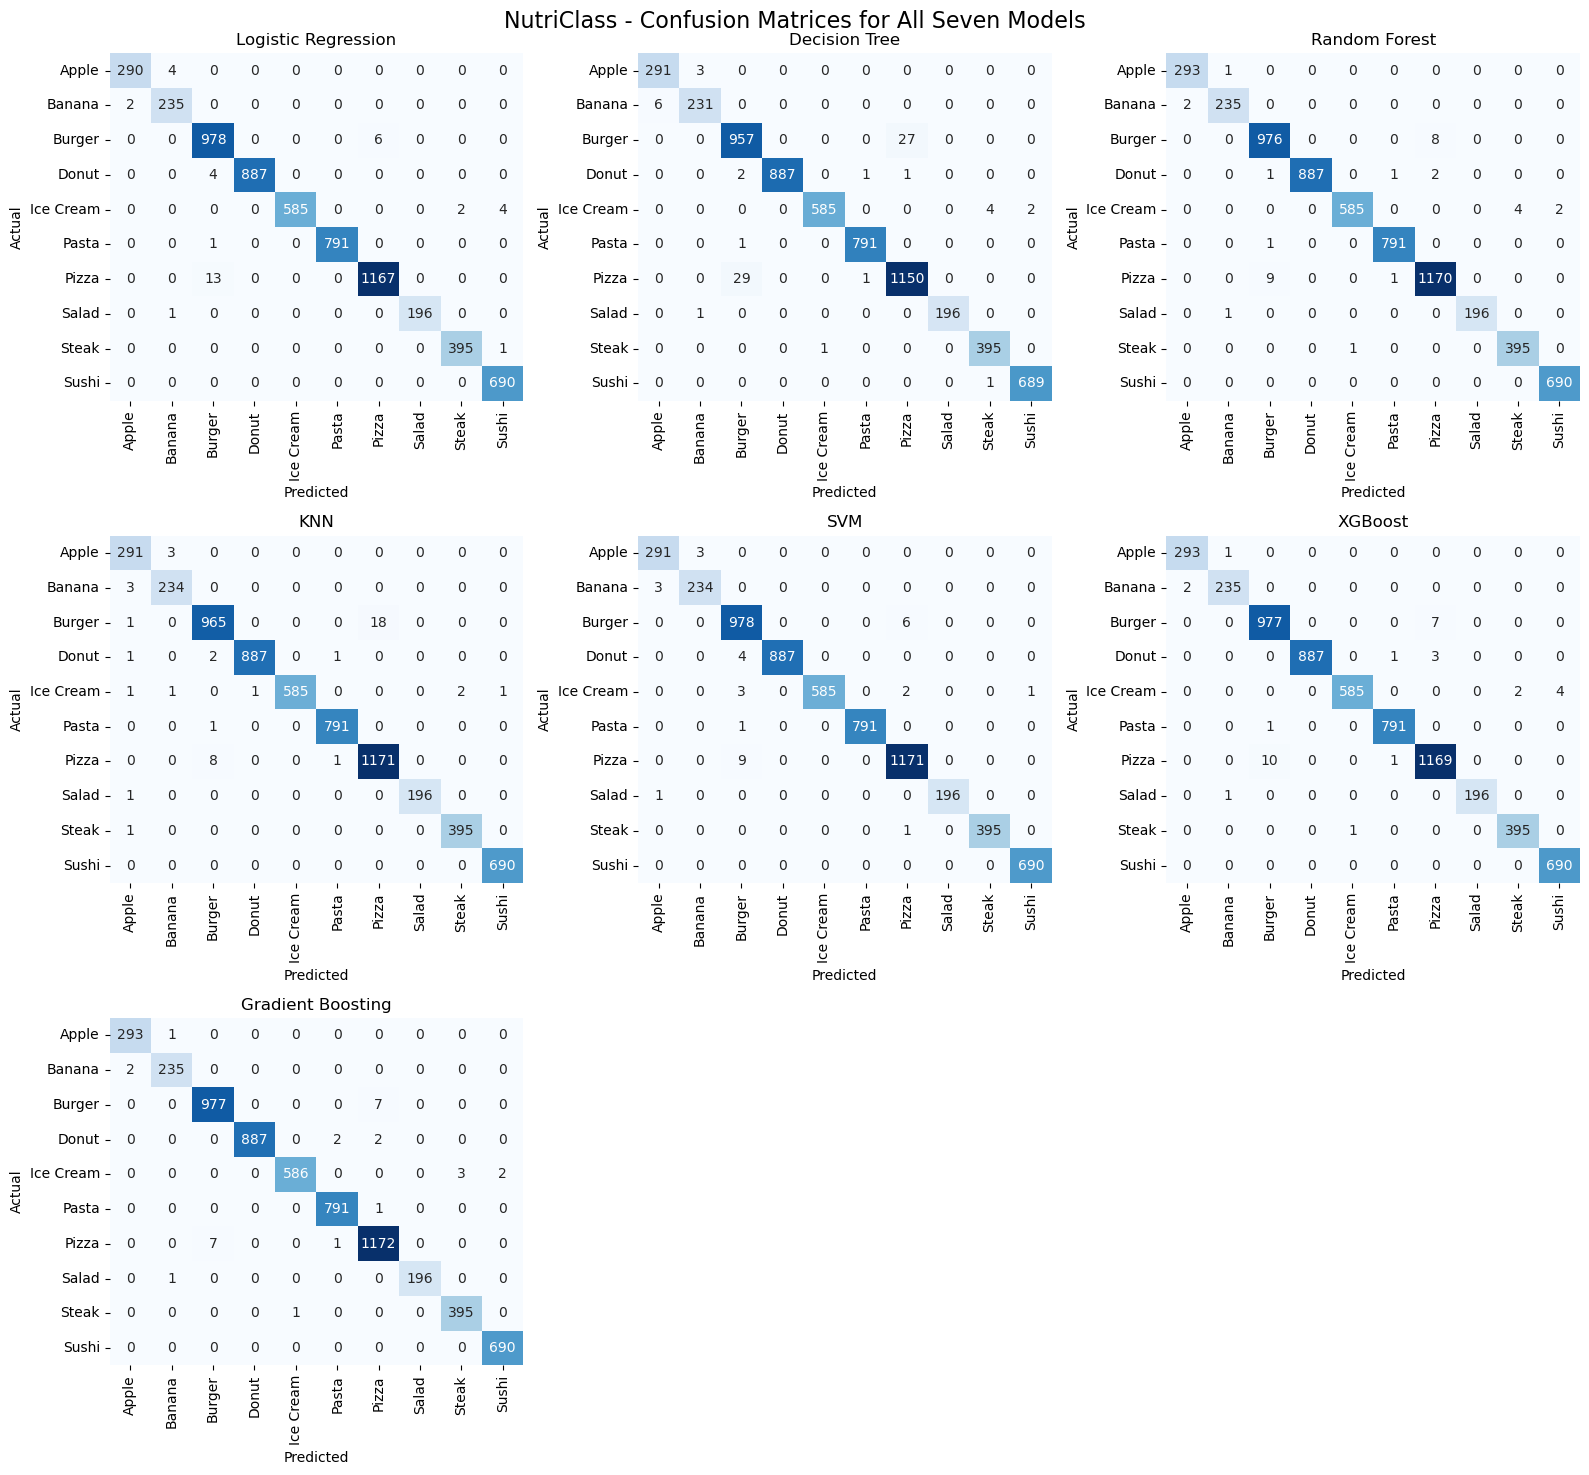

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gradient_boosting_model
}

class_names = label_encoder.classes_

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes = axes.flatten()

for i, (model_name, model) in enumerate(trained_models.items()):

    # Predict only - no retraining
    y_pred = model.predict(X_test)

    # IMPORTANT: use encoded actual labels
    cm = confusion_matrix(
        y_test_encoded,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
        cbar=False
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove unused plots
for j in range(len(trained_models), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "NutriClass - Confusion Matrices for All Seven Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Confusion matrices — benchmark interpretation

These seven confusion matrices provide the required class-level evaluation for every benchmark model.
 
“The diagonal values represent correct classifications. Off-diagonal values show which food categories the model confuses. The matrices confirm that most predictions lie on the diagonal, which is consistent with the very high F1 scores.”

# 11. Final Preprocessing Refinement — Outlier Capping

## Outlier Capping

In [79]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_clean.drop('Food_Name', axis=1)
y = df_clean['Food_Name']

# Same 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

Training shape: (25008, 15)
Testing shape: (6252, 15)


### Outlier-refinement setup

For the final refinement, I recreated the same 80/20 stratified split and kept the test set completely separate.

**Important methodological point:** IQR limits are calculated from the **training data only**, preventing information from the test set from influencing preprocessing.

### Numerical Features

In [80]:
numerical_columns = [
    'Calories',
    'Protein',
    'Fat',
    'Carbs',
    'Sugar',
    'Fiber',
    'Sodium',
    'Cholesterol',
    'Glycemic_Index',
    'Water_Content',
    'Serving_Size'
]

### Calculate Training-Only IQR Bounds

In [81]:
outlier_bounds = {}

for column in numerical_columns:
    
    Q1 = X_train_raw[column].quantile(0.25)
    Q3 = X_train_raw[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_bounds[column] = {
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    }

outlier_bounds_df = pd.DataFrame(outlier_bounds).T

outlier_bounds_df

,Lower_Bound,Upper_Bound
Calories,31.345561,508.327621
Protein,-9.371895,25.896628
Fat,-3.021716,27.062966
Carbs,10.802651,48.864869
Sugar,-12.155177,30.220298
Fiber,-2.145598,5.559223
Sodium,-788.888756,1482.543920
Cholesterol,-20.898262,68.583909
Glycemic_Index,36.883789,98.467510
Water_Content,18.939693,72.349012


### IQR-bound interpretation

The IQR method produced lower and upper bounds for every numerical feature.

These bounds define the range within which the training values are considered non-extreme for the purpose of the final refinement.

### Apply IQR Capping

In [82]:
def cap_outliers(data, bounds):
    
    data = data.copy()
    
    for column, limits in bounds.items():
        
        data[column] = data[column].clip(
            lower=limits['Lower_Bound'],
            upper=limits['Upper_Bound']
        )
    
    return data

In [83]:
X_train_capped = cap_outliers(
    X_train_raw,
    outlier_bounds
)

X_test_capped = cap_outliers(
    X_test_raw,
    outlier_bounds
)

### Verify Capping

In [84]:
remaining_outliers = {}

for column, limits in outlier_bounds.items():
    
    count = (
        (X_train_capped[column] < limits['Lower_Bound']) |
        (X_train_capped[column] > limits['Upper_Bound'])
    ).sum()
    
    remaining_outliers[column] = count

remaining_outliers

{'Calories': 0,
 'Protein': 0,
 'Fat': 0,
 'Carbs': 0,
 'Sugar': 0,
 'Fiber': 0,
 'Sodium': 0,
 'Cholesterol': 0,
 'Glycemic_Index': 0,
 'Water_Content': 0,
 'Serving_Size': 0}

### Capping verification

After applying the IQR bounds, the remaining outlier count is **0 for every numerical feature in the capped training data**.

**Key takeaway:** the capping step successfully limits extreme values without deleting additional rows.

### Before vs After Comparison

In [85]:
comparison = pd.DataFrame({
    'Before_Min': X_train_raw[numerical_columns].min(),
    'After_Min': X_train_capped[numerical_columns].min(),
    'Before_Max': X_train_raw[numerical_columns].max(),
    'After_Max': X_train_capped[numerical_columns].max()
})

comparison

,Before_Min,After_Min,Before_Max,After_Max
Calories,60.786204,60.786204,1289.956763,508.327621
Protein,0.000000,0.000000,81.761772,25.896628
Fat,0.000000,0.000000,88.619611,27.062966
Carbs,0.000000,10.802651,140.585537,48.864869
Sugar,0.000000,0.000000,78.548162,30.220298
Fiber,0.000000,0.000000,18.891993,5.559223
Sodium,0.000000,0.000000,2724.236846,1482.543920
Cholesterol,0.000000,0.000000,260.149443,68.583909
Glycemic_Index,0.000000,36.883789,286.126400,98.467510
Water_Content,13.465039,18.939693,251.837472,72.349012


### Before-vs-after interpretation

The comparison shows that extreme maximum values were reduced substantially—for example, Calories from about 1,290 to about 508, and Cholesterol from about 260 to about 69.

**Why capping instead of deleting:** this preserves all observations while reducing the influence of extreme values.

Outlier Treatment:
Numerical features were analyzed using the Interquartile Range (IQR) method. Because several nutritional variables contained a substantial number of extreme observations, deleting these records could result in unnecessary data loss. Therefore, IQR-based capping was applied. The lower and upper bounds were calculated exclusively from the training dataset to prevent data leakage, and extreme values were capped at these limits in both training and testing datasets.

In [86]:
print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)

comparison

Training shape: (25008, 15)
Testing shape: (6252, 15)


,Before_Min,After_Min,Before_Max,After_Max
Calories,60.786204,60.786204,1289.956763,508.327621
Protein,0.000000,0.000000,81.761772,25.896628
Fat,0.000000,0.000000,88.619611,27.062966
Carbs,0.000000,10.802651,140.585537,48.864869
Sugar,0.000000,0.000000,78.548162,30.220298
Fiber,0.000000,0.000000,18.891993,5.559223
Sodium,0.000000,0.000000,2724.236846,1482.543920
Cholesterol,0.000000,0.000000,260.149443,68.583909
Glycemic_Index,0.000000,36.883789,286.126400,98.467510
Water_Content,13.465039,18.939693,251.837472,72.349012


### Outlier-treatment summary

The final refined data keeps the original training and test sample sizes:

- Training: **25,008**
- Testing: **6,252**

The numerical extremes are capped, not removed.

This satisfies the project requirement to detect and treat outliers while minimizing unnecessary data loss.

# 12. Feature Selection Experiment

## Build Feature-Selection Pipeline

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

In [88]:
numerical_columns = [
    'Calories',
    'Protein',
    'Fat',
    'Carbs',
    'Sugar',
    'Fiber',
    'Sodium',
    'Cholesterol',
    'Glycemic_Index',
    'Water_Content',
    'Serving_Size'
]

categorical_columns = [
    'Meal_Type',
    'Preparation_Method'
]

boolean_columns = [
    'Is_Vegan',
    'Is_Gluten_Free'
]

In [89]:
feature_selection_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_columns),
        ('bool', 'passthrough', boolean_columns)
    ]
)

In [90]:
feature_selection_model = Pipeline([
    ('preprocessor', feature_selection_preprocessor),
    
    ('feature_selection', SelectKBest(
        score_func=f_classif,
        k=15
    )),
    
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

## Train and Evaluate Feature-Selection Model

In [91]:
feature_selection_model.fit(
    X_train_capped,
    y_train
)

print("Feature-selection model trained successfully!")

c:\Users\david\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Feature-selection model trained successfully!


### Feature-selection training note

The feature-selection pipeline completed successfully.

**Technical note:** Scikit-learn may report a runtime warning for encoded features with zero within-class variance during the ANOVA F-test. The model fitting itself completed and produced a valid feature-selection result, which is evaluated below.

In [92]:
y_pred_fs = feature_selection_model.predict(
    X_test_capped
)

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

fs_accuracy = accuracy_score(
    y_test,
    y_pred_fs
)

fs_precision = precision_score(
    y_test,
    y_pred_fs,
    average='weighted'
)

fs_recall = recall_score(
    y_test,
    y_pred_fs,
    average='weighted'
)

fs_weighted_f1 = f1_score(
    y_test,
    y_pred_fs,
    average='weighted'
)

fs_macro_f1 = f1_score(
    y_test,
    y_pred_fs,
    average='macro'
)

print("Gradient Boosting + Feature Selection")
print("--------------------------------------")
print(f"Accuracy     : {fs_accuracy:.4f}")
print(f"Precision    : {fs_precision:.4f}")
print(f"Recall       : {fs_recall:.4f}")
print(f"Weighted F1  : {fs_weighted_f1:.4f}")
print(f"Macro F1     : {fs_macro_f1:.4f}")

Gradient Boosting + Feature Selection
--------------------------------------
Accuracy     : 0.9946
Precision    : 0.9946
Recall       : 0.9946
Weighted F1  : 0.9946
Macro F1     : 0.9954


### Feature-selection result interpretation

Feature selection reduced the processed feature space from **21 to 15 features**.

Performance remained extremely high:

- Accuracy: **99.46%**
- Macro F1: **99.54%**

**Decision:** retain the full-feature model for the final system because it gives slightly higher accuracy while maintaining comparable Macro F1.

## Inspect Selected Features

In [94]:
# Get all processed feature names
processed_features = (
    feature_selection_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Get selection mask
selection_mask = (
    feature_selection_model
    .named_steps['feature_selection']
    .get_support()
)

selected_features = processed_features[selection_mask]

print("Selected Features:")
for feature in selected_features:
    print(feature)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
num__Calories
num__Protein
num__Fat
num__Carbs
num__Sugar
num__Fiber
num__Sodium
num__Cholesterol
num__Glycemic_Index
num__Water_Content
num__Serving_Size
cat__Meal_Type_dinner
cat__Meal_Type_lunch
bool__Is_Vegan
bool__Is_Gluten_Free

Number of selected features: 15


### Selected-feature interpretation

The selected 15 features include all 11 numerical nutritional variables, two Meal Type categories, and both Boolean dietary flags.

Preparation Method was not selected, and several Meal Type categories were also excluded, supporting the later conclusion that these variables contribute relatively little compared with the major nutritional predictors.

### Feature Selection Result

- Processed features: **21**
- Selected features: **15**
- Accuracy: **99.46%**
- Macro F1: **99.54%**

The feature-selected model slightly improves Macro F1 but reduces accuracy compared with the final full-feature model. Therefore, the full-feature model is retained for the final implementation.

### Feature-selection conclusion

The feature-selection experiment demonstrates that the classification task can be performed with a smaller feature set while preserving very high performance.

However, because the full-feature model delivers higher holdout accuracy and the extra features do not materially hurt performance, the final model keeps all 21 processed features.

# 13. Final Model — Gradient Boosting with Outlier Capping

## Train the Final Model

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

capped_gb_model = Pipeline([
    ('preprocessor', feature_selection_preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

print("Fresh Gradient Boosting pipeline created.")

Fresh Gradient Boosting pipeline created.


In [96]:
capped_gb_model.fit(
    X_train_capped,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


### Final-model training

The final Gradient Boosting classifier was trained on the **outlier-capped training data** using the full 21-feature processed representation.

This is the model that will be used for the final holdout evaluation, cross-validation, interpretation, saving, and prediction demo.

In [97]:
gb_classifier = capped_gb_model.named_steps['classifier']

print("Number of estimators:", len(gb_classifier.estimators_))
print("Expected estimators:", gb_classifier.n_estimators)

Number of estimators: 200
Expected estimators: 200


### Model-training verification

The final classifier contains **200 boosting estimators**, matching the configured model specification.

This check confirms that the intended estimator was fully fitted before prediction.

In [101]:
y_pred_capped_gb = capped_gb_model.predict(
    X_test_capped
)

print("Prediction completed successfully.")
print("Number of predictions:", len(y_pred_capped_gb))

Prediction completed successfully.
Number of predictions: 6252


### Prediction verification

The final model produced predictions for all **6,252** test records.

No rows were lost during prediction, so the final evaluation covers the complete holdout set.

In [102]:
capped_gb_accuracy = accuracy_score(
    y_test,
    y_pred_capped_gb
)

capped_gb_precision = precision_score(
    y_test,
    y_pred_capped_gb,
    average='weighted'
)

capped_gb_recall = recall_score(
    y_test,
    y_pred_capped_gb,
    average='weighted'
)

capped_gb_weighted_f1 = f1_score(
    y_test,
    y_pred_capped_gb,
    average='weighted'
)

capped_gb_macro_f1 = f1_score(
    y_test,
    y_pred_capped_gb,
    average='macro'
)

print("Gradient Boosting + Outlier Capping")
print("-----------------------------------")
print(f"Accuracy     : {capped_gb_accuracy:.4f}")
print(f"Precision    : {capped_gb_precision:.4f}")
print(f"Recall       : {capped_gb_recall:.4f}")
print(f"Weighted F1  : {capped_gb_weighted_f1:.4f}")
print(f"Macro F1     : {capped_gb_macro_f1:.4f}")

Gradient Boosting + Outlier Capping
-----------------------------------
Accuracy     : 0.9950
Precision    : 0.9950
Recall       : 0.9950
Weighted F1  : 0.9950
Macro F1     : 0.9952


### Final holdout performance

The final capped Gradient Boosting model achieved:

- **Accuracy:** 99.50%
- **Precision:** 99.50%
- **Recall:** 99.50%
- **Weighted F1:** 99.50%
- **Macro F1:** 99.52%

The test set contains **6,252 records**, with **6,221 correct predictions and 31 misclassifications**.

**Interpretation:** the model correctly classifies more than 99% of the unseen holdout records while maintaining very similar performance across the imbalanced classes.

## Final Holdout Performance

The final Gradient Boosting model was evaluated on an unseen holdout test set of 6,252 records.

- **Accuracy:** 99.50%
- **Precision:** 99.50%
- **Recall:** 99.50%
- **Weighted F1:** 99.50%
- **Macro F1:** 99.52%

The model correctly classified **6,221 out of 6,252 records**, resulting in only **31 misclassifications**.

This demonstrates that the final model performs consistently across the ten food categories with very high predictive accuracy.

### Why this is the final holdout result

This is the result from the **refined final model**, not the earlier benchmark.

The final pipeline includes:
- missing-value and duplicate handling
- IQR-based outlier capping
- standardization
- categorical encoding
- Gradient Boosting

This is the performance figure that should be quoted as the project's final holdout result.

# 14. Five-Fold Stratified Cross-Validation

In [104]:
from sklearn.model_selection import cross_val_score

In [106]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation configured successfully.")

5-Fold Stratified Cross-Validation configured successfully.


In [107]:
capped_gb_cv_scores = cross_val_score(
    capped_gb_model,
    X_train_capped,
    y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Gradient Boosting + Outlier Capping - 5 Fold CV")
print("-----------------------------------------------")

print("CV Scores:", capped_gb_cv_scores)

print("\nMean Macro F1:",
      capped_gb_cv_scores.mean())

print("Std Macro F1:",
      capped_gb_cv_scores.std())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  4.4min remaining:  3.0min


Gradient Boosting + Outlier Capping - 5 Fold CV
-----------------------------------------------
CV Scores: [0.99492689 0.99543362 0.9969043  0.99533881 0.99420139]

Mean Macro F1: 0.9953610025401378
Std Macro F1: 0.0008855148849407571


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.5min finished


### Cross-validation interpretation

The final capped model was validated using **5-fold stratified cross-validation** with Macro F1 as the scoring metric.

Results:

- Mean Macro F1: **99.5361%**
- Standard deviation: **0.0886 percentage points**

**What this tells us:** performance remains very consistent across different folds, so the final result is not dependent on one particular train/validation split.

### Cross-Validation Result

- **Mean Macro F1:** 99.54%
- **Standard deviation:** 0.09 percentage points

The low variation across folds indicates stable model performance.

### Cross-validation conclusion

The low standard deviation indicates stable performance across the five folds.

**Evaluator-ready answer:**  
“I used 5-fold stratified cross-validation because the target classes are imbalanced. Macro F1 was selected as the scoring metric so that every food class contributes equally to the validation assessment.”

# 15. Final Confusion Matrix

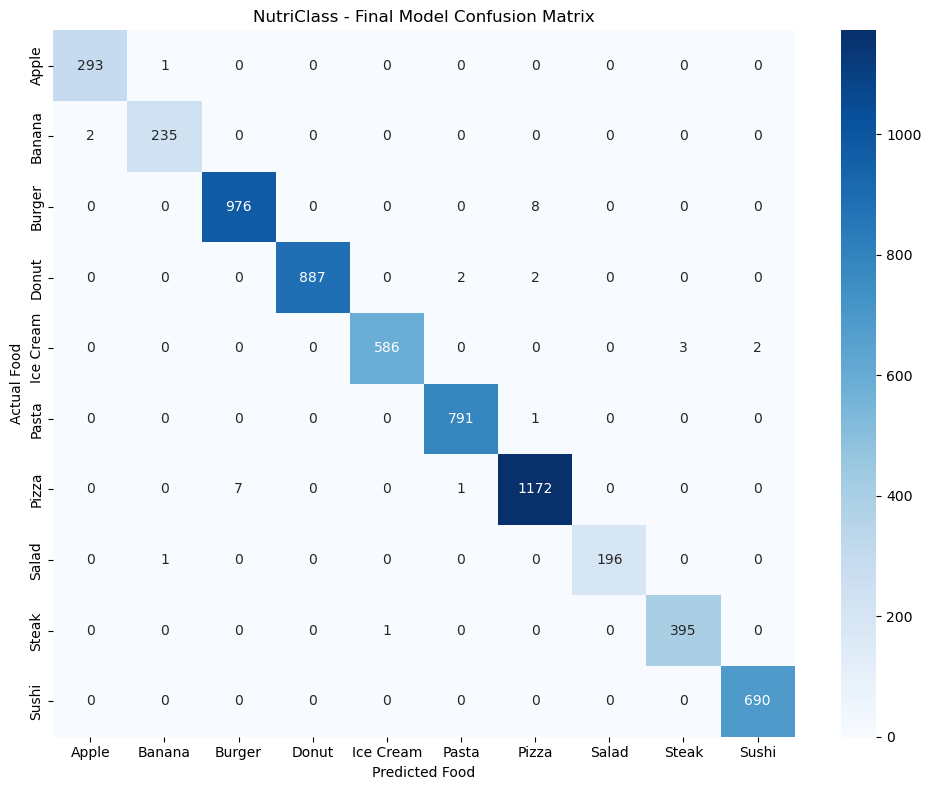

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate predictions from the final model
y_pred_final = capped_gb_model.predict(X_test_capped)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Class names
class_names = sorted(y_test.unique())

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('NutriClass - Final Model Confusion Matrix')
plt.xlabel('Predicted Food')
plt.ylabel('Actual Food')
plt.tight_layout()

plt.show()

### Final confusion-matrix interpretation

This is the confusion matrix for the **locked final model**.

The strong diagonal confirms that most test records are classified correctly. The largest areas of confusion are between nutritionally similar classes, particularly **Burger and Pizza**.

**Key takeaway:** the remaining 31 errors are concentrated in a small number of class overlaps rather than widespread model failure.

# 16. Final Feature Importance

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Get processed feature names
feature_names = capped_gb_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get feature importance
importances = capped_gb_model.named_steps[
    'classifier'
].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(
    by='Importance',
    ascending=False
)

# Display all features
print(feature_importance_df)

                            Feature  Importance
10                num__Serving_Size    0.256133
6                       num__Sodium    0.183777
7                  num__Cholesterol    0.178292
1                      num__Protein    0.129087
20             bool__Is_Gluten_Free    0.083512
4                        num__Sugar    0.072136
0                     num__Calories    0.038431
2                          num__Fat    0.018554
5                        num__Fiber    0.015585
8               num__Glycemic_Index    0.011405
3                        num__Carbs    0.010699
9                num__Water_Content    0.001596
19                   bool__Is_Vegan    0.000430
16    cat__Preparation_Method_fried    0.000089
11         cat__Meal_Type_breakfast    0.000072
14             cat__Meal_Type_snack    0.000047
12            cat__Meal_Type_dinner    0.000046
15    cat__Preparation_Method_baked    0.000033
13             cat__Meal_Type_lunch    0.000027
17  cat__Preparation_Method_grilled    0

### Final feature-importance interpretation

The final model identifies the following as the strongest predictors:

1. **Serving Size:** 25.61%
2. **Sodium:** 18.38%
3. **Cholesterol:** 17.83%
4. **Protein:** 12.91%
5. **Is Gluten Free:** 8.35%
6. **Sugar:** 7.21%

The top four features together contribute approximately **74.7%** of total feature importance.

**Important interpretation:** feature importance shows how useful a feature is to the trained model; it does not mean the feature independently causes the food classification.

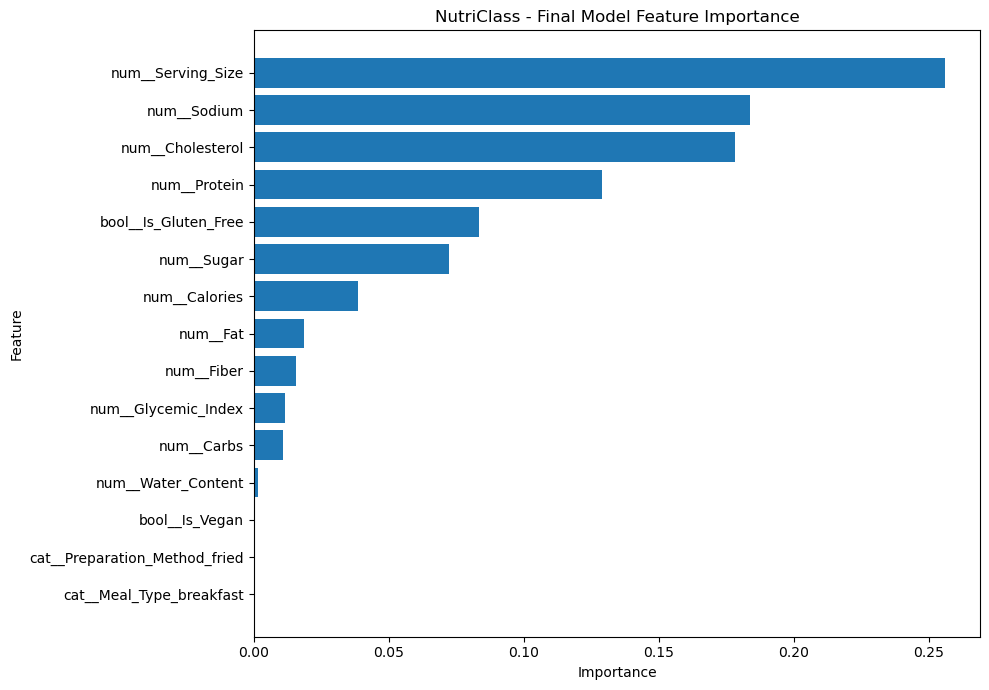

In [110]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('NutriClass - Final Model Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Feature-importance visualization

The bar chart provides a visual summary of which inputs the final Gradient Boosting model relies on most heavily.

**Business interpretation:** nutritional and serving-related information dominates the classification signal, while individual Meal Type and Preparation Method indicators contribute very little.

### Feature Importance Insight

The four strongest features are:

1. **Serving Size:** 25.61%
2. **Sodium:** 18.38%
3. **Cholesterol:** 17.83%
4. **Protein:** 12.91%

Together they contribute approximately **74.7%** of total feature importance.

Meal Type and Preparation Method have very low individual importance in this model, indicating that nutritional and serving-related attributes provide the strongest predictive signals in this dataset.

### Feature-importance conclusion

The final model's decisions are driven mainly by **Serving Size, Sodium, Cholesterol, and Protein**.

This supports the project's core premise that nutritional characteristics are highly informative for food classification.

# 17. Save the Final Model

In [111]:
import joblib
from pathlib import Path

# Create models folder if it doesn't exist
Path("models").mkdir(exist_ok=True)

# Save the final trained model
model_path = "models/nutriclass_final_model.pkl"

joblib.dump(capped_gb_model, model_path)

print("Final model saved successfully!")
print(f"Location: {model_path}")

Final model saved successfully!
Location: models/nutriclass_final_model.pkl


### Model artifact

The final trained pipeline has been saved as:

`models/nutriclass_final_model.pkl`

The saved object contains the preprocessing steps and Gradient Boosting classifier together, so the same transformations used during training can be reused for future predictions.

In [112]:
import os

print("File exists:", os.path.exists(model_path))
print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

File exists: True
File size: 3.37 MB


### Saved-model verification

The model file exists and is approximately **3.37 MB**.

This confirms that the trained final pipeline has been successfully persisted for reuse without retraining.

# 18. NutriClass Prediction Demo

In [113]:
import joblib
import pandas as pd

# Load the saved final model
final_model = joblib.load("models/nutriclass_final_model.pkl")

def predict_food(
    calories,
    protein,
    fat,
    carbs,
    sugar,
    fiber,
    sodium,
    cholesterol,
    glycemic_index,
    water_content,
    serving_size,
    meal_type,
    preparation_method,
    is_vegan,
    is_gluten_free
):
    
    # Create input DataFrame
    input_data = pd.DataFrame([{
        'Calories': calories,
        'Protein': protein,
        'Fat': fat,
        'Carbs': carbs,
        'Sugar': sugar,
        'Fiber': fiber,
        'Sodium': sodium,
        'Cholesterol': cholesterol,
        'Glycemic_Index': glycemic_index,
        'Water_Content': water_content,
        'Serving_Size': serving_size,
        'Meal_Type': meal_type,
        'Preparation_Method': preparation_method,
        'Is_Vegan': is_vegan,
        'Is_Gluten_Free': is_gluten_free
    }])

    # Prediction
    prediction = final_model.predict(input_data)[0]

    # Prediction probabilities
    probabilities = final_model.predict_proba(input_data)[0]

    # Get class names
    classes = final_model.named_steps['classifier'].classes_

    # Create probability table
    probability_df = pd.DataFrame({
        'Food': classes,
        'Probability': probabilities
    }).sort_values(
        by='Probability',
        ascending=False
    )

    return prediction, probability_df

In [114]:
prediction, probabilities = predict_food(
    calories=403,
    protein=25,
    fat=25,
    carbs=1,
    sugar=0.5,
    fiber=0.1,
    sodium=100,
    cholesterol=80,
    glycemic_index=2,
    water_content=2,
    serving_size=200,
    meal_type='dinner',
    preparation_method='grilled',
    is_vegan=False,
    is_gluten_free=True
)

print("Predicted Food:", prediction)

print("\nTop 3 Predictions:")

for _, row in probabilities.head(3).iterrows():
    print(
        f"{row['Food']}: "
        f"{row['Probability'] * 100:.2f}%"
    )

Predicted Food: Steak

Top 3 Predictions:
Steak: 100.00%
Burger: 0.00%
Pizza: 0.00%


### Prediction-demo interpretation

For the demonstrated steak-like nutritional profile, the final saved model predicts:

**Steak — 100.00% model probability**

Top alternatives are Burger and Pizza with effectively zero probability for this particular input.

**What I would say:**  
“This demonstrates that the saved final pipeline can take a new raw nutritional profile, apply the same preprocessing, and return the predicted food class.”

### Prediction Interpretation

For the demonstrated steak-like nutritional profile, the model predicted:

**Steak — 100.00% model probability**

The probability is the model's output for the supplied profile; it is not a guarantee of real-world food identity.

### Prediction caveat

The displayed percentage is the model's predicted probability for this input; it is not a guarantee of real-world identity.

The implemented system is a **classifier**: it predicts the most likely food among the predefined classes. A full recommendation engine that optimizes a user's nutrition goals would be an additional layer beyond this project.

# 19. Business Insights

- Nutritional and serving characteristics provide the strongest classification signals.
- Serving Size, Sodium, Cholesterol, and Protein are the dominant predictors.
- Automated classification can support food logging and nutrition-focused applications.
- The model can provide a single predicted food category for a supplied nutritional profile.

### Business-insight interpretation

The model can support applications such as automated food logging, nutrition-focused classification, and dietary tracking by converting a structured nutritional profile into a predefined food category.

The strongest predictive signals are nutritional and serving-related, which aligns with the project's domain objective.

# 20. Limitations

- The dataset is synthetic, so the very high classification performance may not represent real-world performance.
- The model classifies among the predefined food categories; it is not a complete diet recommendation or optimization system.
- Real-world deployment should be validated on independently collected food and nutrition data.
- Prediction quality depends on the quality and consistency of the input nutritional measurements.

### Limitations

1. The dataset is **synthetic**, so the very high performance may not transfer directly to real-world food data.
2. The model performs classification among the predefined ten food classes; it is not a complete nutrition recommendation or optimization engine.
3. Nutritional profiles in real applications may be noisier and less distinctly separated than in this dataset.

These limitations should be mentioned during the live evaluation if asked about deployment readiness.

# 21. Conclusion

NutriClass successfully demonstrates a multi-class food classification workflow using nutritional and food-related attributes.

Seven machine learning classifiers were benchmarked, and the final Gradient Boosting model with IQR-based outlier capping achieved:

- **99.50% test accuracy**
- **99.52% test Macro F1**
- **99.54% mean Macro F1 in 5-fold stratified cross-validation**

The model also provides interpretable feature importance and a reusable prediction function for new nutritional profiles.

The project therefore meets the core requirements for data preprocessing, feature engineering, multi-class classification, evaluation, visualization, and validation.

### Conclusion

NutriClass completed the requested multi-class food-classification workflow from data understanding through final prediction.

The final Gradient Boosting model achieved **99.50% holdout accuracy** and **99.52% Macro F1**, with **99.54% mean Macro F1** in five-fold stratified cross-validation.

The final analysis shows that Serving Size, Sodium, Cholesterol, and Protein are the dominant predictive signals.

**Final takeaway:** the project demonstrates a reproducible end-to-end classification workflow with preprocessing, model comparison, validation, interpretation, and reusable prediction capability.

# 22. Requirement Coverage — Final Check

This final notebook covers the project requirements end-to-end:

- Data understanding and EDA
- Missing-value and duplicate handling
- Outlier detection and IQR capping
- Numerical standardization and categorical encoding
- Feature selection experiment
- Seven required classification models
- Accuracy, Precision, Recall, F1-score, and confusion matrices
- Five-fold stratified cross-validation
- Reproducibility with fixed random seeds
- Feature importance and visual interpretation
- Reusable saved-model prediction
- Business insights, limitations, and conclusion

**Final model:** Gradient Boosting with outlier capping and the full processed feature set.

**Final holdout accuracy:** 99.50%  
**Final holdout Macro F1:** 99.52%  
**Five-fold CV mean Macro F1:** 99.54%

In [116]:
from pathlib import Path

# Create deployment data folder
Path("data").mkdir(exist_ok=True)

# Save the original raw dataset for the Streamlit lookup feature
deployment_data_path = "data/synthetic_food_dataset_imbalanced.csv"

df.to_csv(
    deployment_data_path,
    index=False
)

print("Deployment dataset saved successfully!")
print(f"Location: {deployment_data_path}")

Deployment dataset saved successfully!
Location: data/synthetic_food_dataset_imbalanced.csv
